# [XAI Project] Prices Prediction - Regression

__The Used Car Price Prediction dataset is a detailed automotive dataset collected from the marketplace [Cars.com](https://www.cars.com). It contains 4,009 individual vehicle listings, with each record describing a car through nine key attributes that provide meaningful insights into vehicle characteristics and pricing trends.__

### Variable Descriptions:
* **Brand & Model:** Specifies the manufacturer and model name of each vehicle.
* **Model Year:** Indicates the production year of the vehicle, helping assess depreciation and technological updates.
* **Mileage:** Represents the total distance driven, which can reflect vehicle condition and maintenance needs.
* **Fuel Type:** Identifies the fuel source used by the vehicle, such as gasoline, diesel, electric, or hybrid.
* **Engine Type:** Provides details about the engine configuration and performance characteristics.
* **Transmission:** Describes the transmission system, including automatic, manual, or other types.
* **Exterior & Interior Colors:** Captures the visual appearance of the vehicle through its exterior and interior color schemes.
* **Accident History:** Shows whether the vehicle has been involved in previous accidents or sustained damage.
* **Clean Title:** Indicates if the vehicle holds a clean legal title, an important factor in resale value and ownership status.
* **Price:** Displays the listed selling price of each vehicle, useful for market analysis and budget evaluation.

In [1]:
#Adding needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as ticker
import os
import warnings
warnings.filterwarnings("ignore")

In [6]:
#Checking the current working directory
print(os.getcwd())

c:\Users\stran\Desktop\UW\4th sem\XAI\Explainable-AI-Prices-Prediction\Code


In [10]:
#Loading the dataset
df_cars = pd.read_csv('../Data/used_cars_.csv')

In [11]:
#Checking basic info about the dataset
df_cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [12]:
#Cleaning the integer column by removing uncessary signs as mi, ., $ and spaces
df_cars['milage'] = df_cars['milage'].astype(str).str.replace("mi.","")
df_cars['milage'] = df_cars['milage'].str.replace(",","").astype(int)

df_cars['price'] = df_cars['price'].str.replace("$","")
df_cars['price'] = df_cars['price'].str.replace(",","").astype(int)

## Data exploration 

### 1) Top 20 brand of cars count

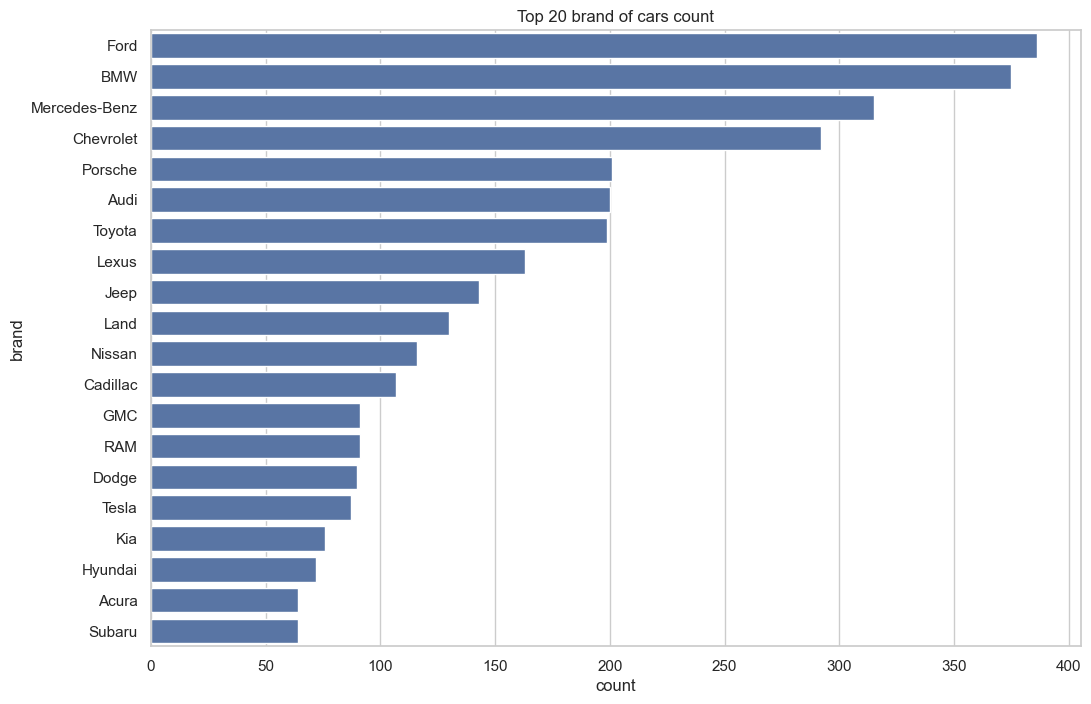

In [13]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(12,8))

sns.barplot(df_cars['brand'].value_counts().nlargest(20).reset_index(), x='count', y='brand', orient='y', errorbar=None)
plt.title("Top 20 brand of cars count")
plt.show()

The bar chart displays the 20 most common car brands in the dataset. **Ford**, **BMW**, and **Mercedes-Benz** have the highest number of listings, while brands such as **Acura** and **Subaru** appear less frequently. The plot indicates that the dataset is dominated by a few major manufacturers.

### 2) Median price of each car

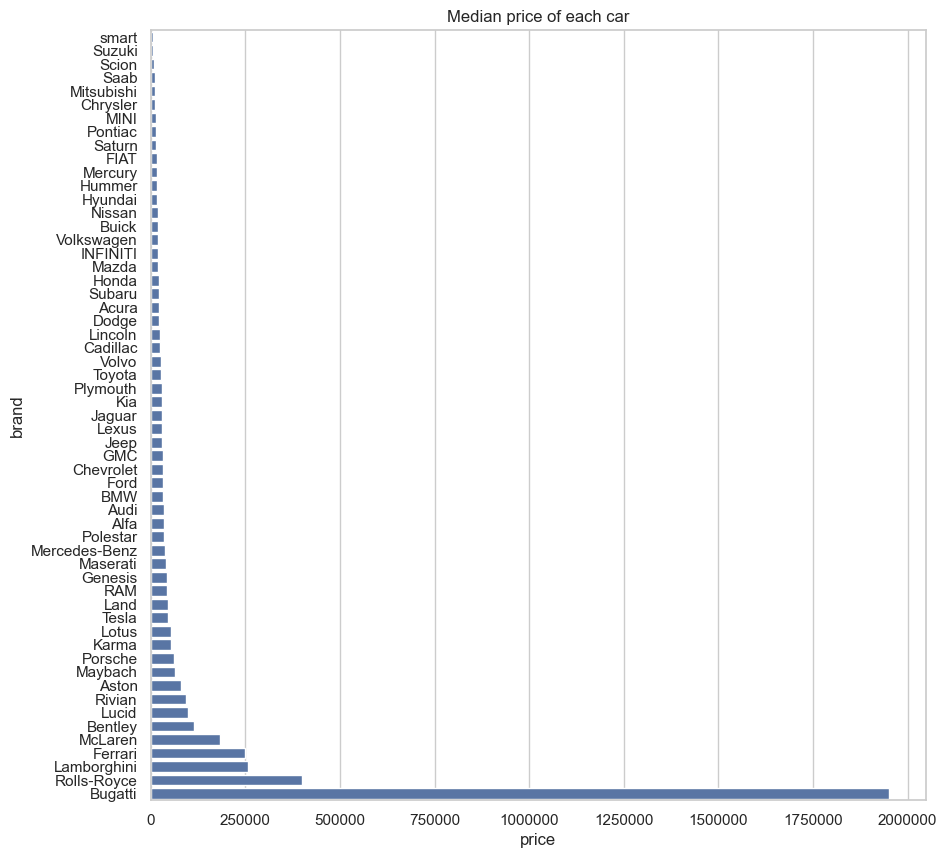

In [14]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10,10))

sns.barplot(df_cars.groupby('brand')['price'].median().reset_index().sort_values('price'), x='price', y='brand', orient='y', errorbar=None)
plt.title("Median price of each car")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

The bar chart compares the median price of vehicles across different car brands. Luxury brands such as **Bugatti**, **Rolls-Royce**, and **Lamborghini** have the highest median prices, while brands like **smart**, **Suzuki**, and **Scion** have the lowest. The plot highlights the strong relationship between brand and vehicle price.

### 3) Price distribution of top 20 brands

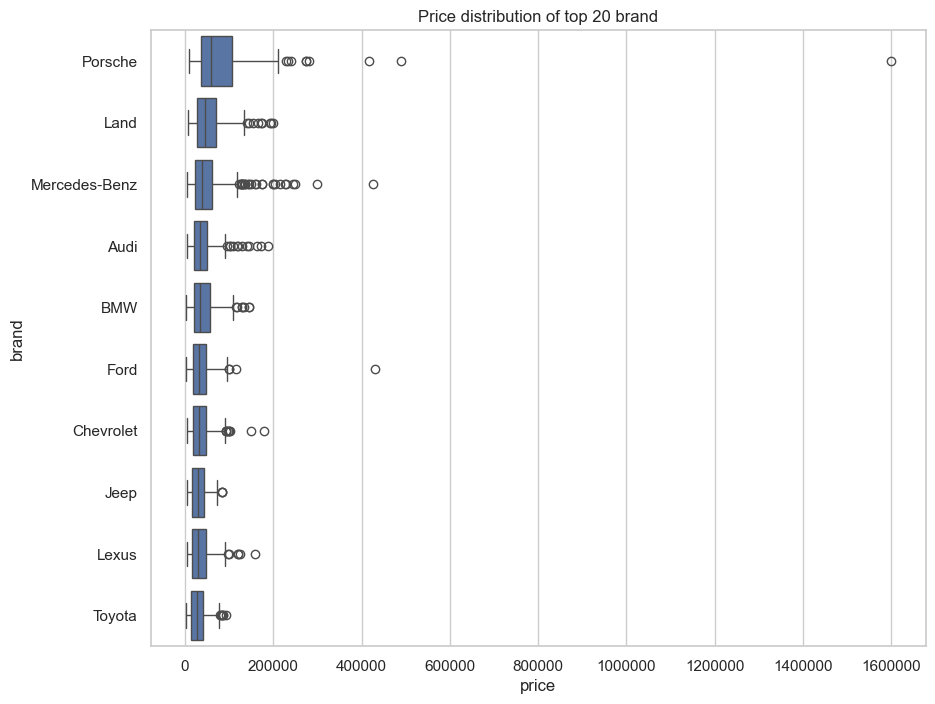

In [15]:
plt.figure(figsize=(10,8))

sns.boxplot(df_cars[df_cars['brand'].isin(df_cars['brand'].value_counts().nlargest(20).index)] , 
            x='price', 
            y='brand',
           order=df_cars[df_cars['brand'].isin(df_cars['brand'].value_counts().nlargest(10).index)].groupby(['brand'])['price'].median().sort_values(ascending=False).index)

plt.title("Price distribution of top 20 brand")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

The boxplot compares the price distributions of the most common car brands in the dataset. **Porsche**, **Land Rover**, and **Mercedes-Benz** show higher median prices and greater variability, indicating a wider range of vehicle values. In contrast, brands such as **Toyota**, **Jeep**, and **Ford** have lower and more concentrated price distributions.

Several brands contain noticeable outliers, representing luxury or high-performance vehicles with exceptionally high prices. Overall, the plot highlights significant differences in pricing patterns across car brands.

### 4) Individual car distribution

Text(0.5, 1.0, 'Individual car distribution')

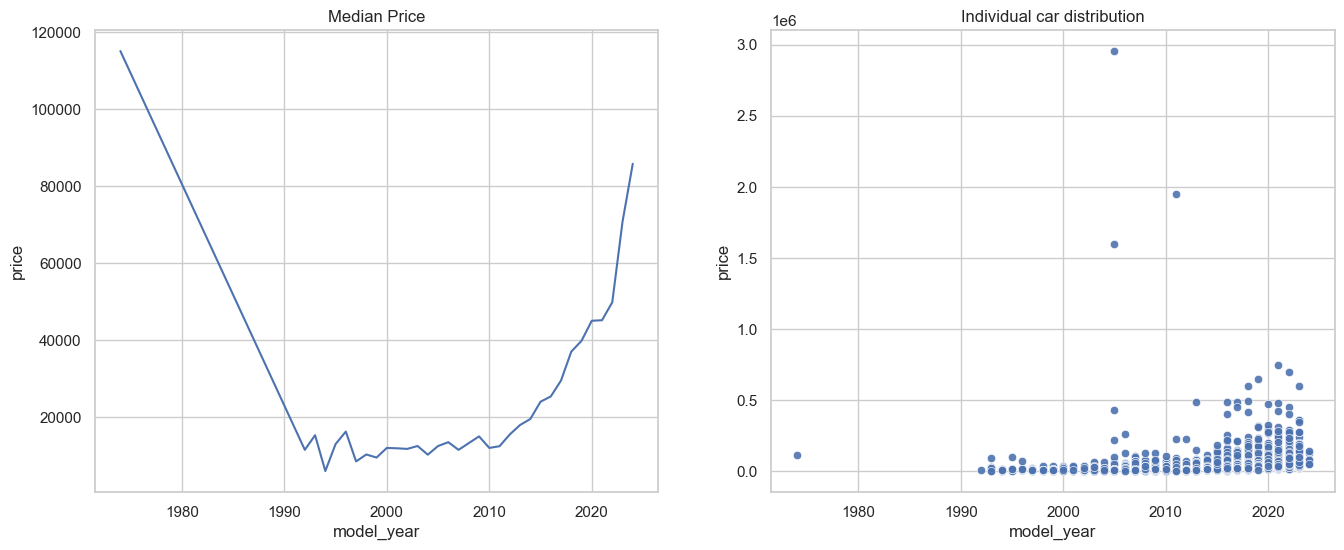

In [16]:
fig, axes = plt.subplots(1,2, figsize=(16, 6))

sns.lineplot(df_cars, x='model_year', y='price', estimator='median', errorbar=None, ax=axes[0])
axes[0].set_title('Median Price')

sns.scatterplot(df_cars, x='model_year', y='price', alpha=0.9, ax=axes[1])
axes[1].set_title('Individual car distribution')

The first plot shows the median vehicle price by model year. Prices generally increase for newer vehicles, indicating that recent car models tend to have higher market values. Older vehicles display lower median prices overall.

The second scatter plot illustrates the distribution of individual car prices across model years. Most vehicles are concentrated in the lower price range, while a few extreme outliers represent luxury or exotic cars with exceptionally high prices. The plot also shows that newer model years contain a wider range of vehicle prices.

### 5) Distribution of Price (Zoomed in < $150k)

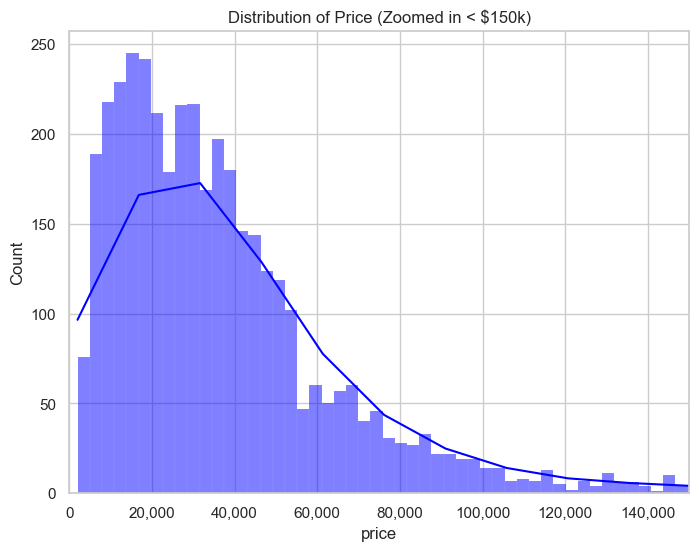

In [17]:
plt.figure(figsize=(8,6))

sns.histplot(df_cars['price'], kde=True, bins=1000, color='blue')
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlim(0, 150000)
plt.title('Distribution of Price (Zoomed in < $150k)')
plt.show()

The histogram illustrates the distribution of vehicle prices below \$150,000. Most cars are priced between approximately \$10,000 and \$40,000, while higher-priced vehicles appear less frequently. The distribution is positively skewed, with a long tail extending toward more expensive cars.

### 6) Distribution of Price (Log Scale)

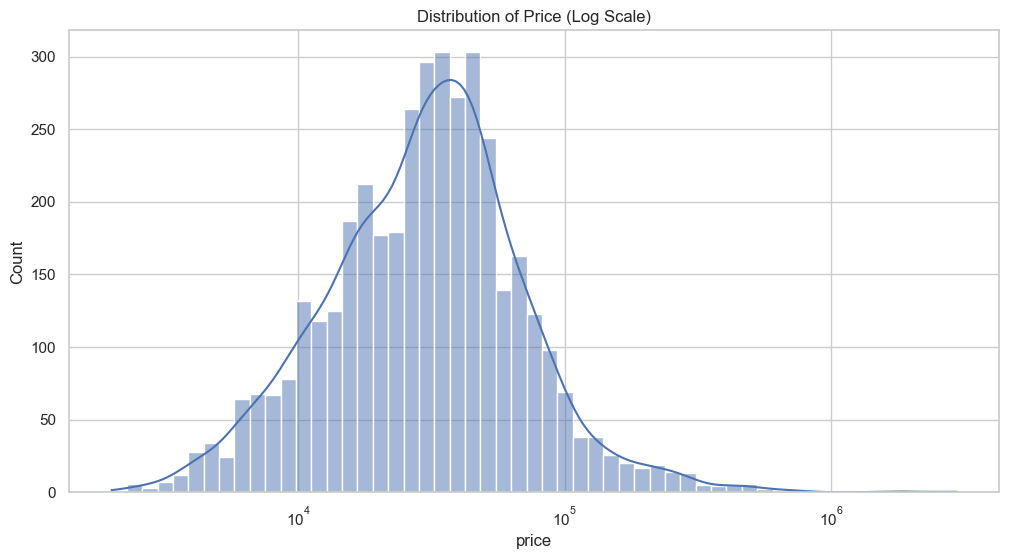

In [18]:
plt.figure(figsize=(12, 6))

sns.histplot(df_cars['price'], kde=True, log_scale=True) 

plt.title('Distribution of Price (Log Scale)')
plt.show()

The histogram shows the distribution of car prices on a logarithmic scale. Most vehicles are concentrated in the mid-price range, while a smaller number of luxury and exotic cars create a long right tail. Applying the log scale reduces skewness and makes the distribution appear more balanced, which is useful for regression modeling.

## Data Cleaning & Engineering